In [1]:
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

import seaborn as sns
import seaborn.objects as so


# Model Performance Comparisons
Generates graphs for performance, model size, and efficiency.

In [2]:
#styling
mpl.rcParams['figure.dpi'] = 150
sns.set_theme(style = 'whitegrid')
model_palette = ['#779cdfff', '#64d0d0ff', '#bfde76ff']
model_dict = {'Baseline': '#779cdfff', 'Diphone': '#bfde76ff', 'Reduced':'#64d0d0ff'}
sns.set_palette(model_palette)

In [3]:
df = pd.read_csv("/home/ivyb/capstone-proj-b2t-p/comparison_analyses/b2t_performance_data_fortmatted.csv")
df['Model'] = pd.Categorical(df['Model'], categories=['Baseline', 'Reduced', 'Diphone'], ordered=True)
df['PER'] = pd.to_numeric(df['PER'], errors = 'coerce')
df.head(6)

,Model,Version,Model Size,RNN Through,RNN Median Latency,Language Through,Language Median Latency,WER,PER,Number of Classes
0,Baseline,Validation,169.048984,81.626602,9.652257,3.232961,224.012017,7.136051,10.099,41.0
1,Baseline,Test,169.048984,90.732139,9.714007,3.372304,296.483027,7.485000,NaN,41.0
2,Diphone,Validation,171.498459,86.403851,9.762287,1.788540,415.033460,8.332451,11.038,876.0
3,Diphone,Test,171.498459,84.420200,9.785533,1.776832,430.022478,8.709000,NaN,876.0
4,Reduced,Validation,169.028450,95.039266,9.588838,2.836698,257.082582,7.157226,9.350,34.0
5,Reduced,Test,169.028450,99.131246,9.643674,2.715374,270.388126,6.858000,NaN,34.0


## Model Size

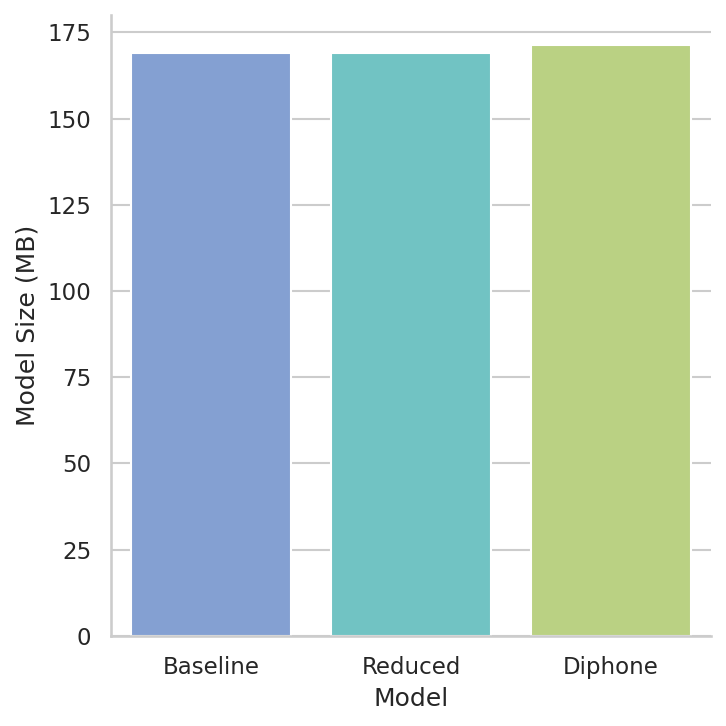

In [4]:
# graphs model size in MB
g = sns.catplot(data = df, kind = 'bar', x = 'Model', y = 'Model Size', hue = 'Model', palette = model_dict, legend = False)
g.set_axis_labels('Model', 'Model Size (MB)')

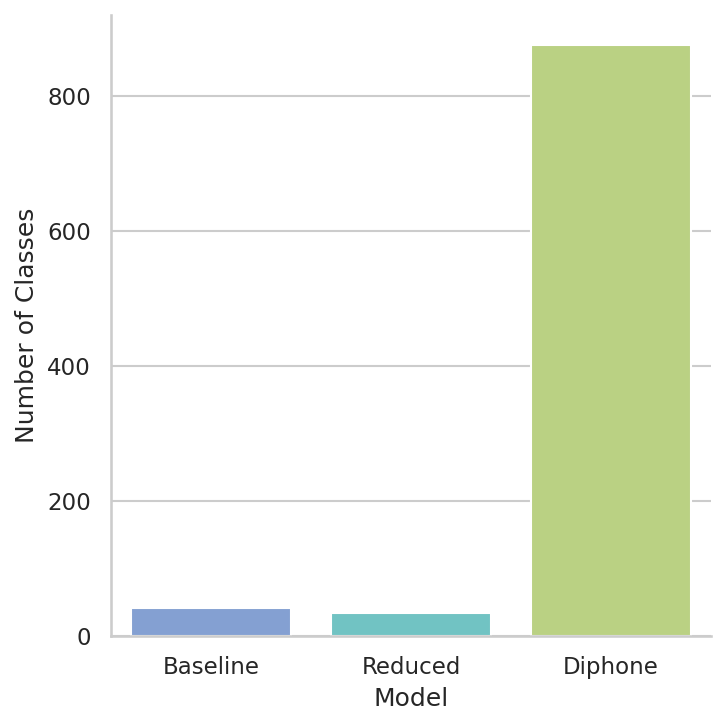

In [5]:
#graphs class prediction sizes
c = sns.catplot(data = df, kind = 'bar', x = 'Model', y = 'Number of Classes', hue = 'Model', palette = model_dict, legend = False)
c.set_axis_labels('Model', 'Number of Classes')

## Model Accuracy

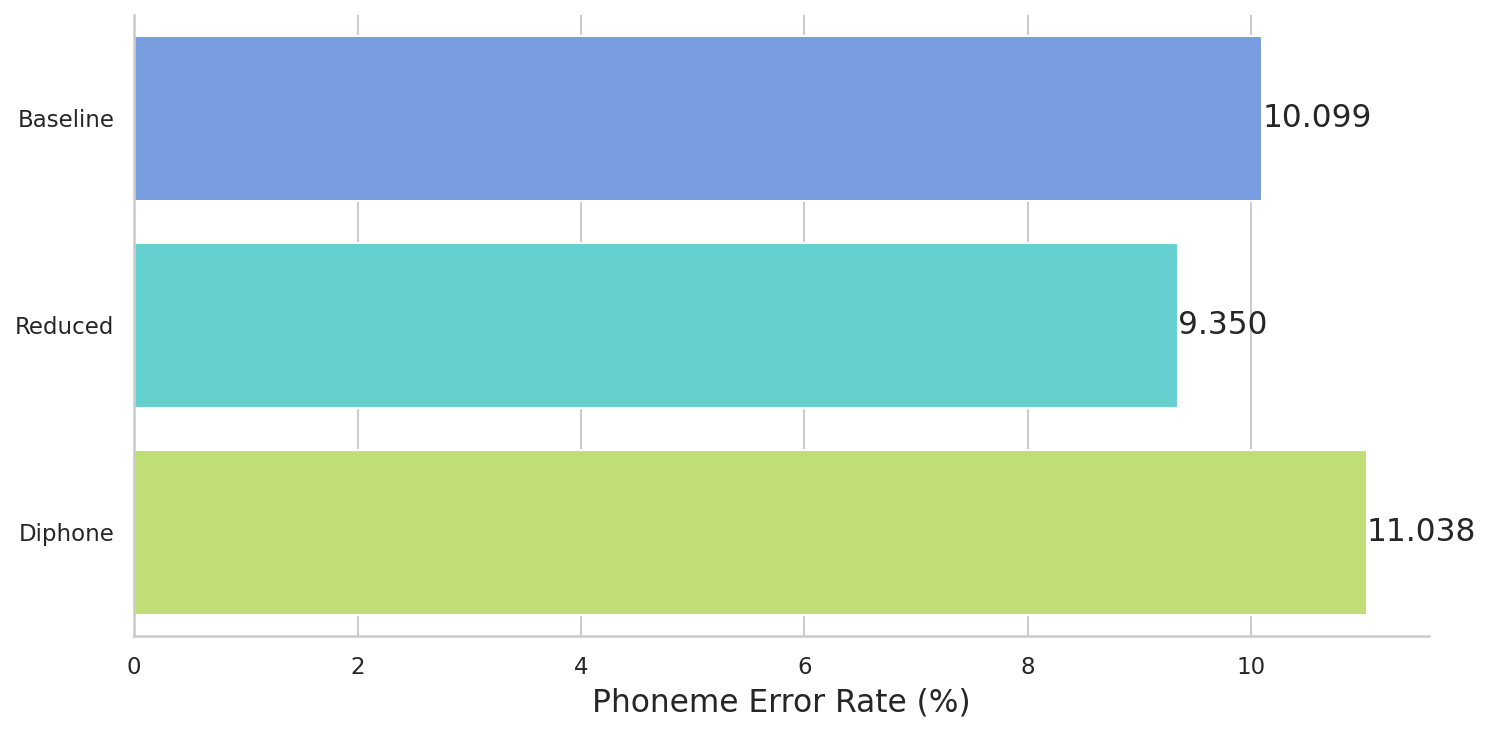

In [6]:
#PER
p = sns.catplot(data = df, kind = 'bar', 
x = 'PER', y = 'Model', hue = 'Model', saturation = 1, 
palette = model_dict, legend = False, orient = 'h', height = 5, aspect = 2)
p.set_axis_labels('Phoneme Error Rate (%)', '', fontsize = 15)
for ax in p.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize = 15, label_type = 'edge')

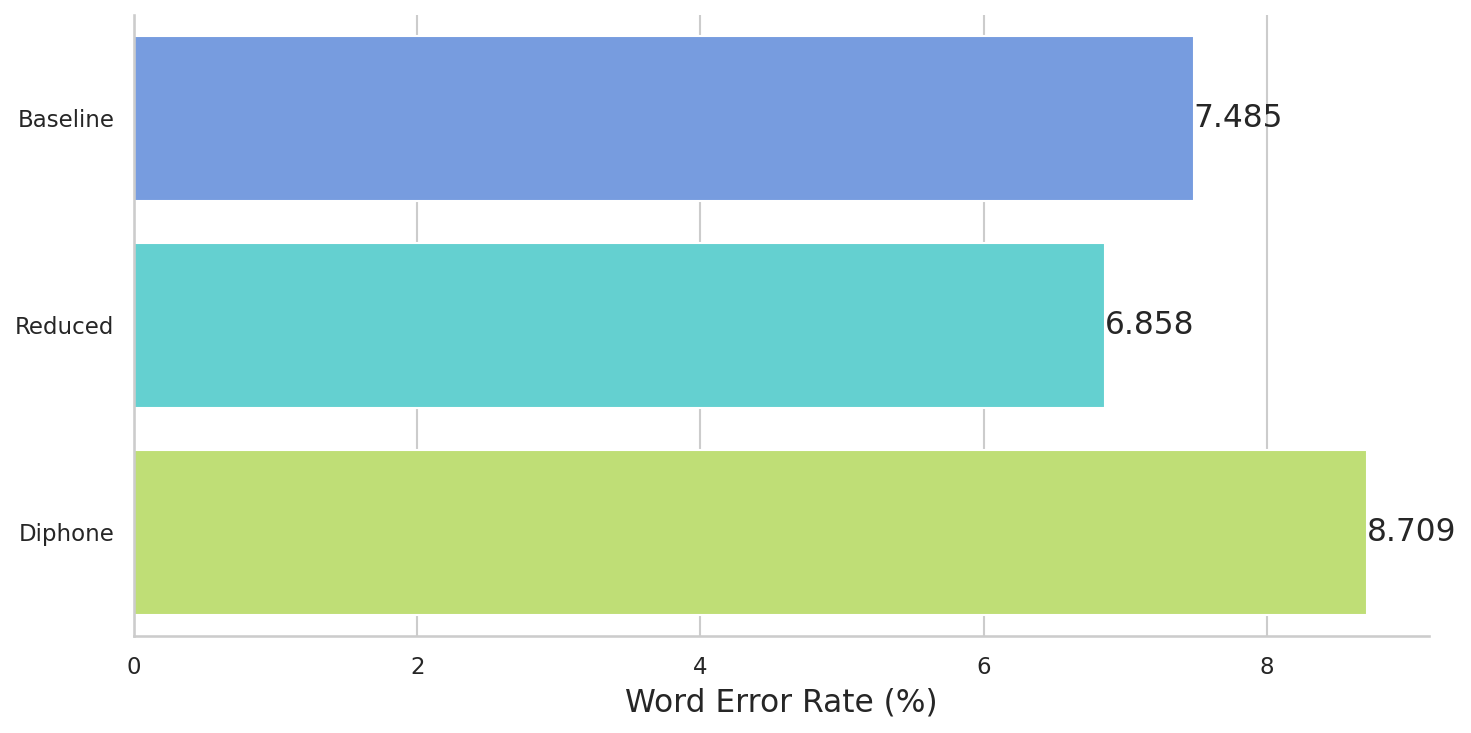

In [7]:
#WER- test trials
w = sns.catplot(data = df[df['Version'] == 'Test'], kind = 'bar', 
    x = 'WER', y = 'Model', hue = 'Model', saturation = 1,
    palette = model_dict, legend = False, orient = 'h', height = 5, aspect = 2)
w.set_axis_labels('Word Error Rate (%)', '', fontsize = 15)
for ax in w.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize = 15, label_type = 'edge')

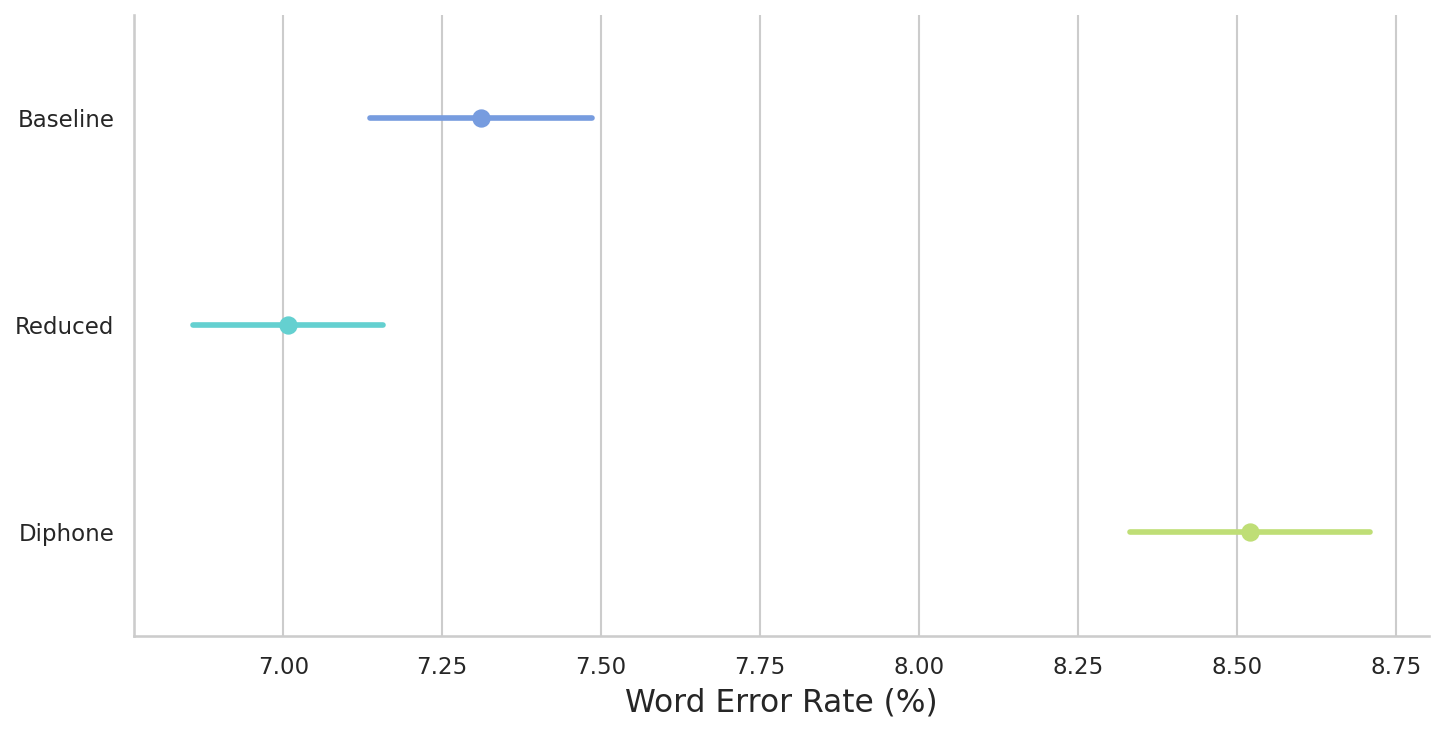

In [8]:
#WER- both trials
w = sns.catplot(data = df, kind = 'point', 
    x = 'WER', y = 'Model', hue = 'Model', saturation = 1,
    palette = model_dict, legend = False, orient = 'h', height = 5, aspect = 2)
w.set_axis_labels('Word Error Rate (%)', '', fontsize = 15)
for ax in w.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize = 15, label_type = 'edge')

## Efficiency

In [9]:
# this separates out based on RNN and language
test_df = df[df['Version'] == 'Test'].copy()
through = test_df.melt(
    id_vars=['Model'],
    value_vars=['RNN Through', 'Language Through'],
    var_name='Type',
    value_name='Through'
)
latency = test_df.melt(
    id_vars=['Model'],
    value_vars=['RNN Median Latency', 'Language Median Latency'],
    var_name='Type',
    value_name='Median Latency'
)
through['Type'] = through['Type'].str.replace(' Through', '')
latency['Type'] = latency['Type'].str.replace(' Median Latency', '')
dfe = through.merge(latency, on=['Model', 'Type'])
dfe.head(6)

,Model,Type,Through,Median Latency
0,Baseline,RNN,90.732139,9.714007
1,Diphone,RNN,84.420200,9.785533
2,Reduced,RNN,99.131246,9.643674
3,Baseline,Language,3.372304,296.483027
4,Diphone,Language,1.776832,430.022478
5,Reduced,Language,2.715374,270.388126


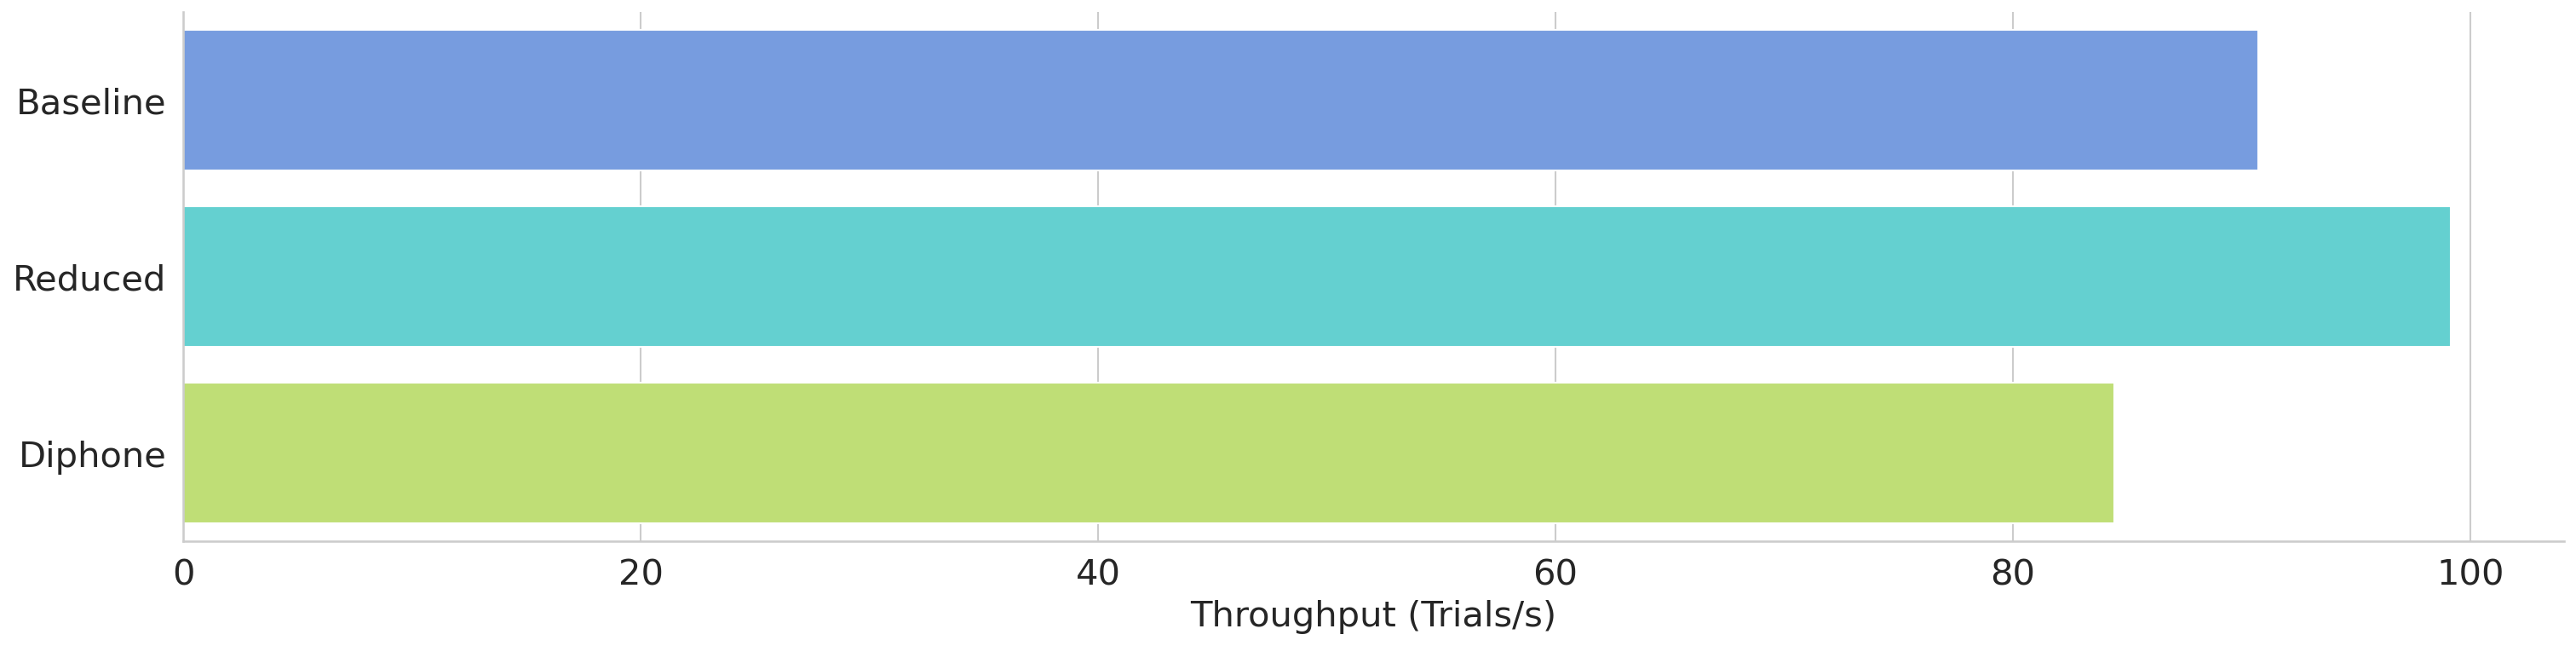

In [10]:
#RNN thruput
t = sns.catplot(data = df[df['Version'] == 'Test'], kind = 'bar', 
    x = 'RNN Through', y = 'Model', hue = 'Model', saturation = 1,
    palette = model_dict, legend = False, orient = 'h', height = 5, aspect = 4)
t.set_axis_labels('Throughput (Trials/s)', '', fontsize = 20)
t.tick_params(labelsize = 20)

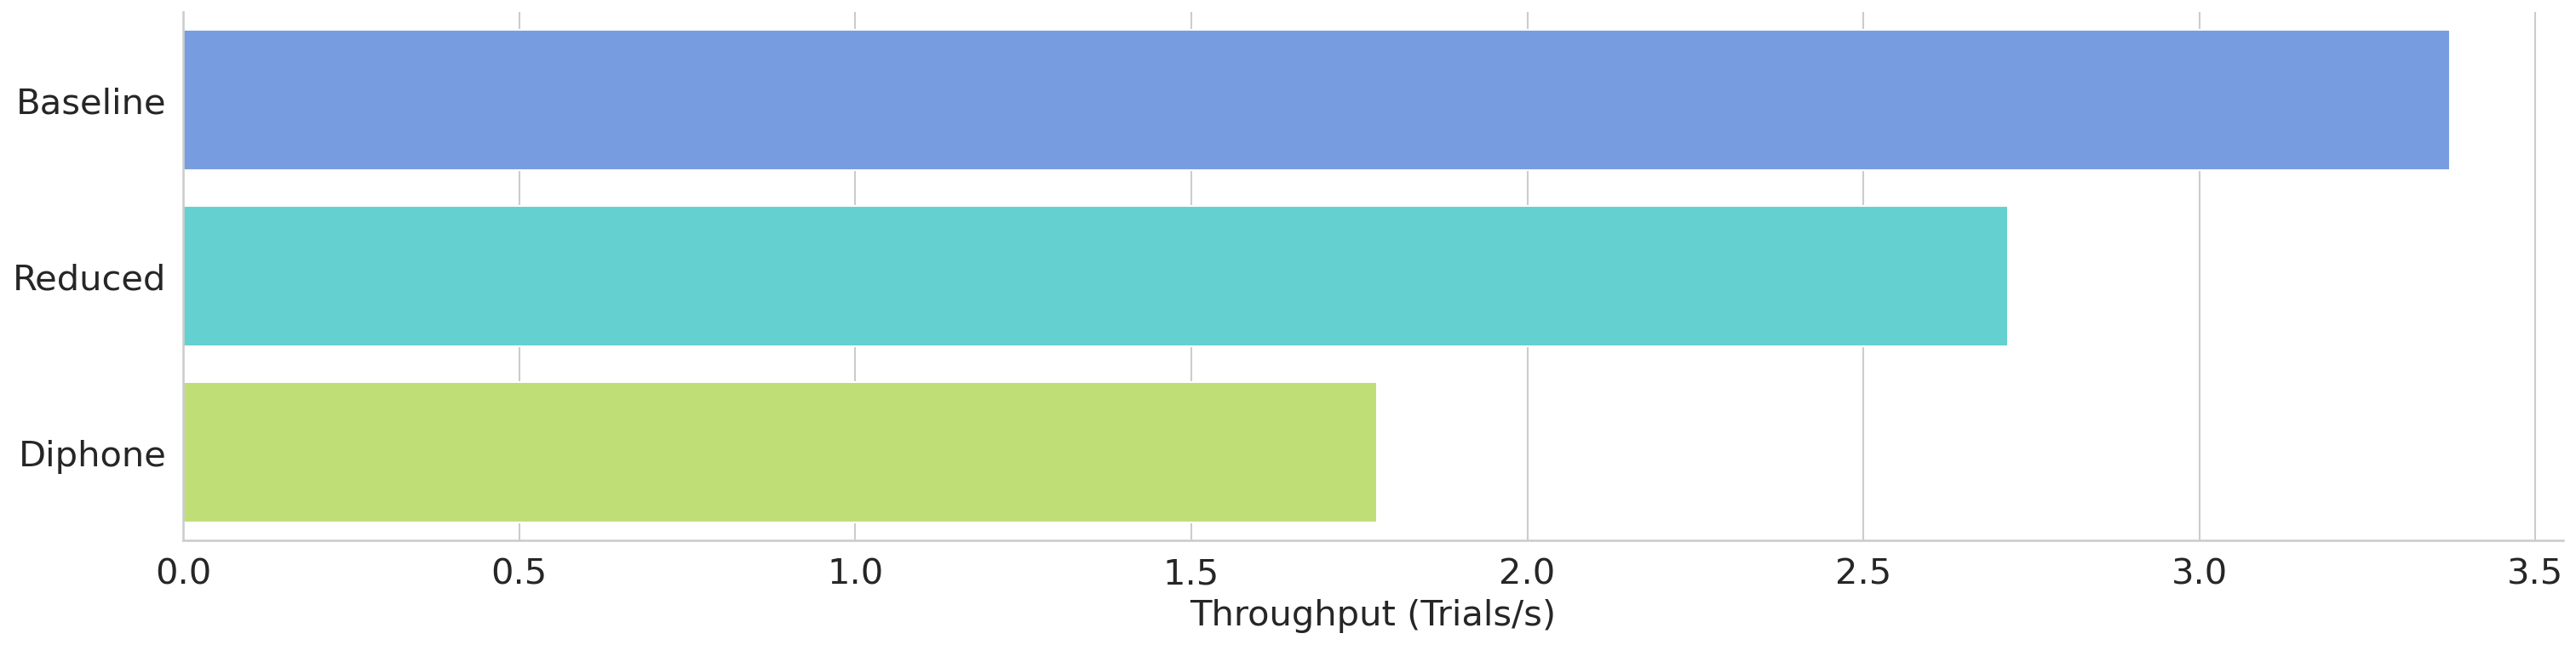

In [11]:
#Language thruput
t = sns.catplot(data = df[df['Version'] == 'Test'], kind = 'bar', 
    x = 'Language Through', y = 'Model', hue = 'Model', saturation = 1,
    palette = model_dict, legend = False, orient = 'h', height = 5, aspect = 4)
t.set_axis_labels('Throughput (Trials/s)', '', fontsize = 20)
t.tick_params(labelsize = 20)

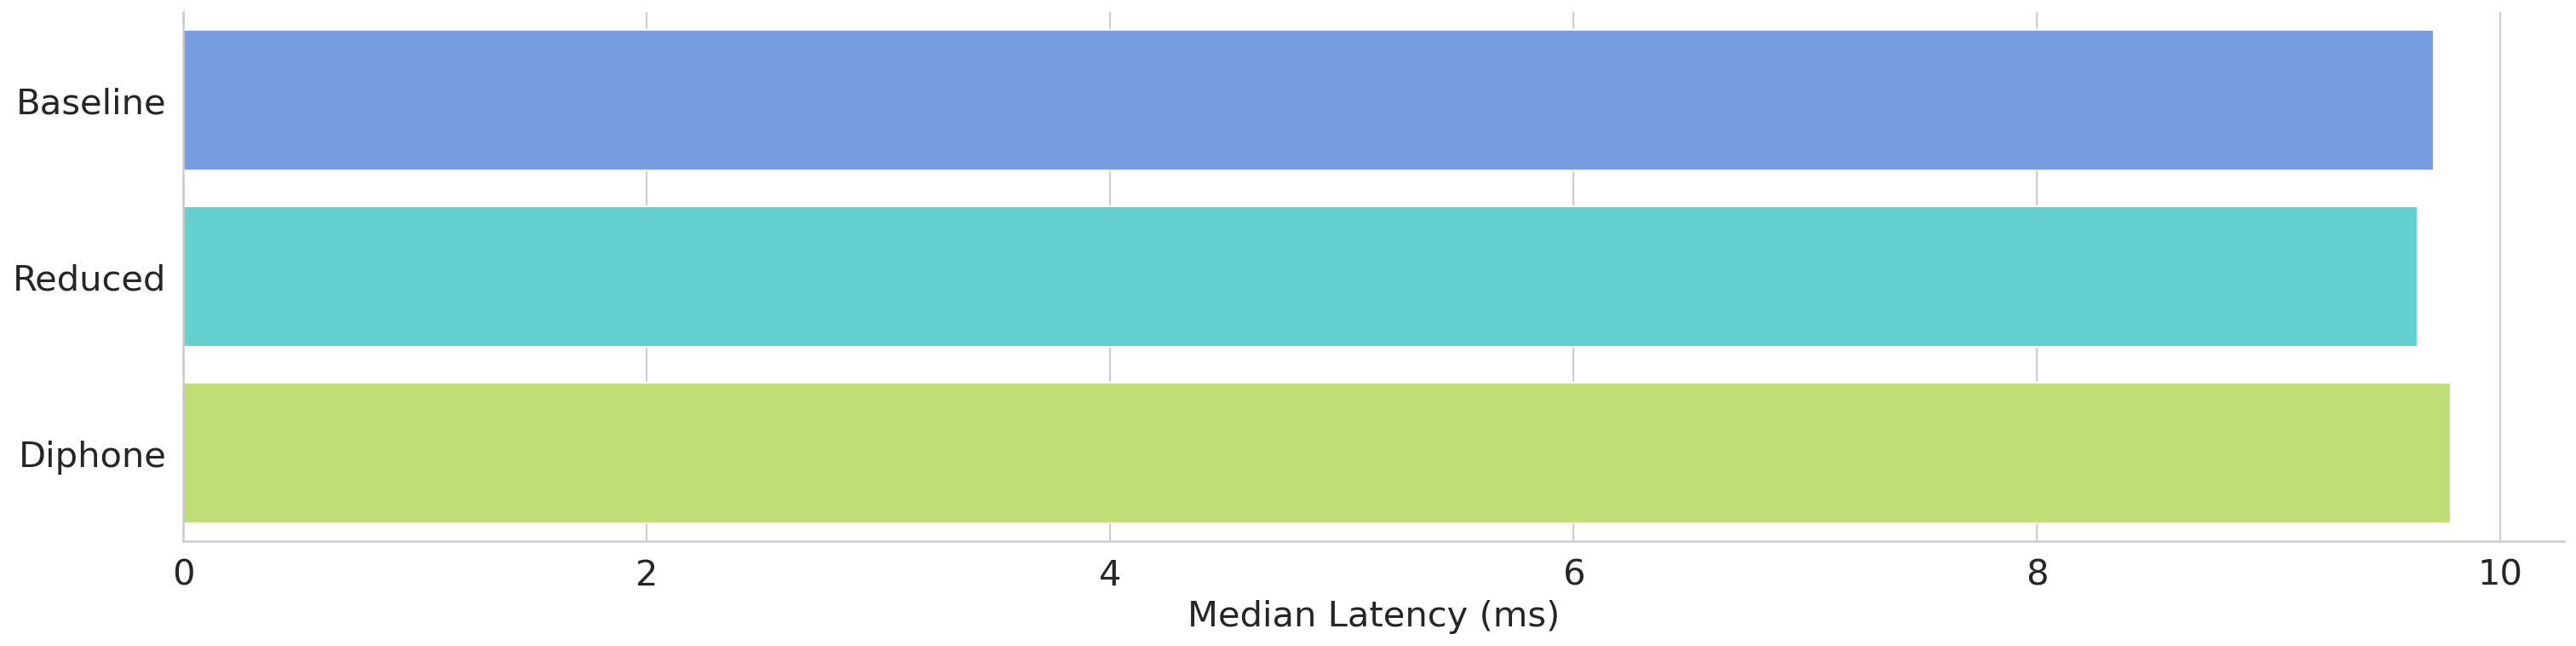

In [15]:
#RNN latency
t = sns.catplot(data = df[df['Version'] == 'Test'], kind = 'bar', 
    x = 'RNN Median Latency', y = 'Model', hue = 'Model', saturation = 1,
    palette = model_dict, legend = False, orient = 'h', height = 5, aspect = 4)
t.set_axis_labels('Median Latency (ms)', '', fontsize = 20)
t.tick_params(labelsize = 20)

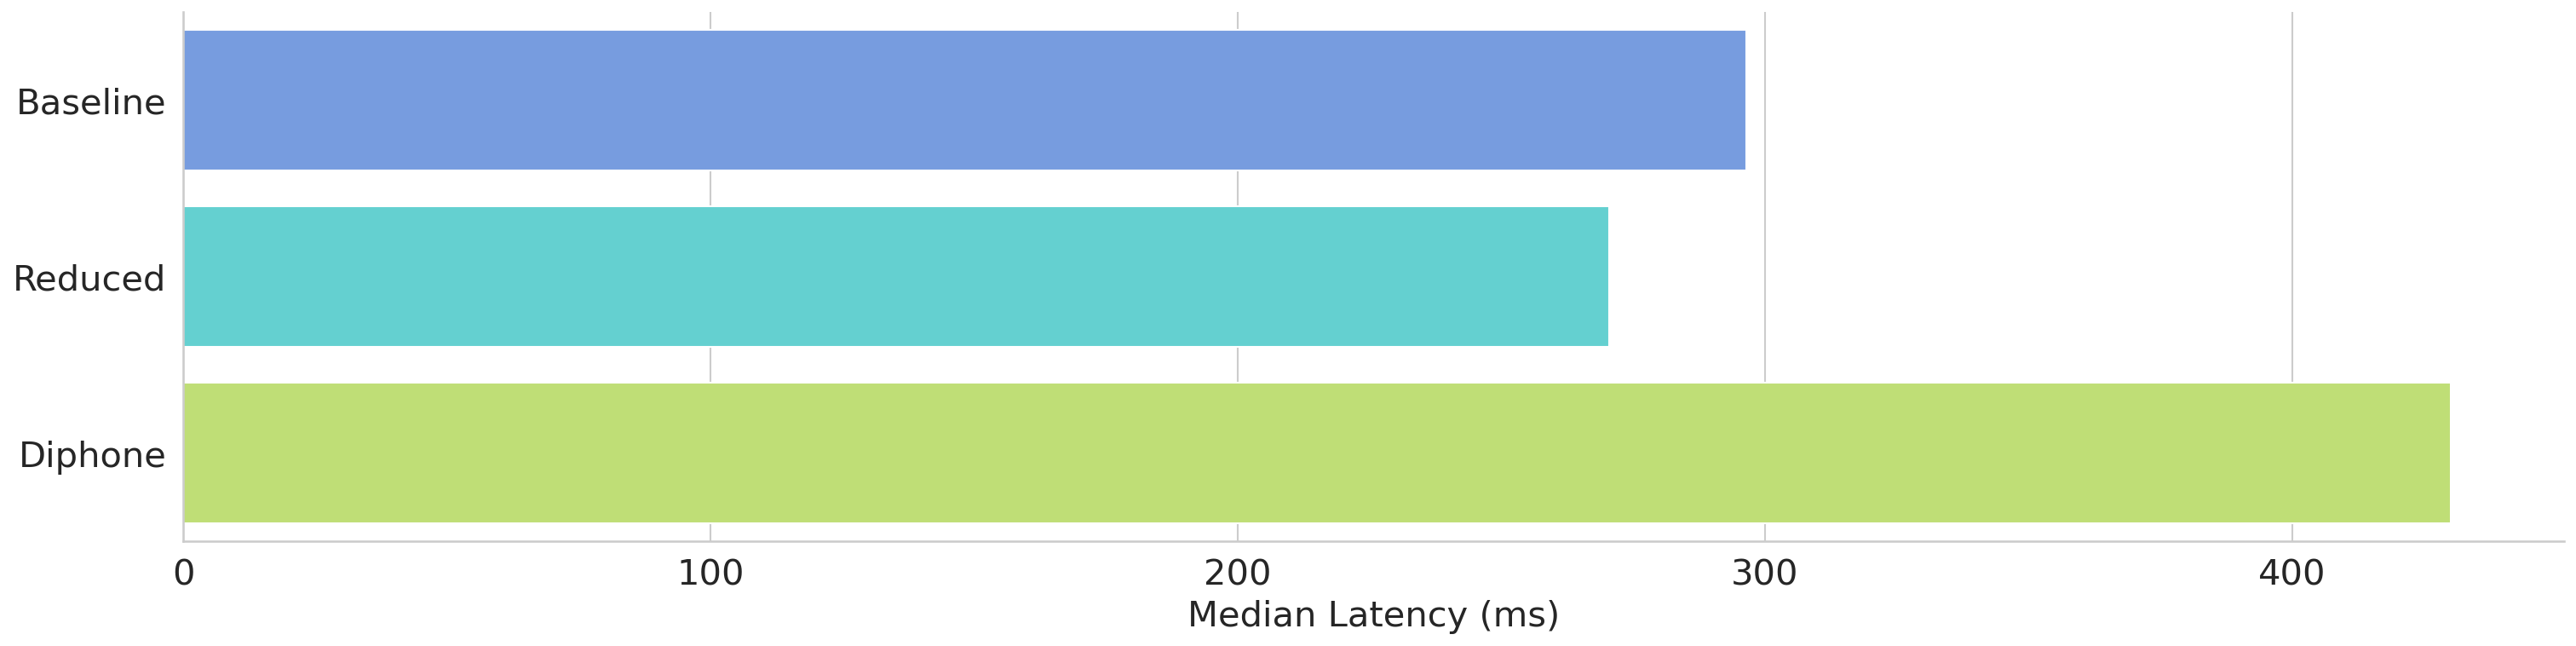

In [16]:
#Language latency
t = sns.catplot(data = df[df['Version'] == 'Test'], kind = 'bar', 
    x = 'Language Median Latency', y = 'Model', hue = 'Model', saturation = 1,
    palette = model_dict, legend = False, orient = 'h', height = 5, aspect = 4)
t.set_axis_labels('Median Latency (ms)', '', fontsize = 20)
t.tick_params(labelsize = 20)